# 🚚 Logistics Optimizer: MC-VRPB — Multi-Commodity VRP con Backhauling

## Optimización de la Cadena de Suministro de Smurfit Westrock (España)

---

### 🎯 Problema Real

Smurfit Westrock opera una red logística compleja en España:

- **1 fábrica de papel** en Mengíbar (Jaén) que produce bobinas de papel
- **7 plantas de cartón** distribuidas por España que transforman el papel en cajas de cartón
- **Cientos de clientes** finales que reciben pedidos de cartón

### 🔄 El Ciclo Operativo

```
📦 Mengíbar (Papel) ──▶ 🏭 Planta(s) Cartón ──▶ 🏪 Clientes ──▶ 📦 Mengíbar
    (carga bobinas)      (descarga papel,        (entrega       (retorno
                          recoge cartón)          cartón)        vacío)
```

### ➗ Modelo Matemático

Resolvemos una variante del **Vehicle Routing Problem (VRP)** con:

| Componente | Descripción |
|---|---|
| **Función Objetivo** | Minimizar distancia total: $\min \sum_{i,j} d_{ij} x_{ij}$ |
| **Restricción de Precedencia** | Cada planta se visita antes que sus clientes |
| **Filtro de Retorno** | Solo clientes con desvío < umbral km respecto a ruta directa |
| **Motor** | Google OR-Tools con Guided Local Search (GLS) |

### 🆕 Extensiones MC-VRPB

| Parámetro | Descripción |
|---|---|
| `n_clientes` | Máximo de clientes que cada camión puede visitar por ruta |
| `varias_plantas` | Si `True`, un camión puede hacer pickup en más de una planta (Milk Run) |
| `max_plantas_ruta` | Límite de plantas por ruta cuando `varias_plantas=True` |

---
## 0. ⚙️ Parámetros de Configuración

In [21]:
# ======================================================================
# 🔧 PARÁMETROS — Modifica estos valores para experimentar
# ======================================================================
N_CLIENTES = 4              # Máximo de clientes por ruta
VARIAS_PLANTAS = False      # True → multi-planta (MC-VRPB)
MAX_PLANTAS_RUTA = 2        # Plantas máximas por ruta (si varias_plantas=True)
MAX_CUSTOMERS_PER_PLANT = 4 # Pre-selección de clientes por planta (DataManager)
THRESHOLD_KM = 100          # Umbral de desvío para filtro de retorno (km)
# ======================================================================

---
## 1. 📂 Carga de Datos y Preprocesamiento

In [22]:
import json
import sys
import numpy as np
from pathlib import Path

ROOT = Path('.').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import DATA_DIR, RESULTS_DIR
from src.utils.data_manager import DataManager
from src.utils.geo import GeoUtils

plants_file = DATA_DIR / 'locations_smurfit.json'
clients_file = DATA_DIR / 'cliente_ubi.json'

with open(plants_file, 'r', encoding='utf-8') as f:
    plants_data = json.load(f)

print(f"🏛️ Fábrica de Papel: {plants_data['paper_plant']['name']}")
print(f"   Ubicación: ({plants_data['paper_plant']['lat']}, {plants_data['paper_plant']['lng']})")
print(f"\n🏭 Plantas de Cartón: {len(plants_data['carton_plants'])}")
for p in plants_data['carton_plants']:
    print(f"   • {p['name']} ({p['id']})")

🏛️ Fábrica de Papel: Smurfit Westrock Paper Mill Mengíbar
   Ubicación: (37.98148, -3.80058)

🏭 Plantas de Cartón: 7
   • Smurfit Westrock Alcalá (CP_ALCALA)
   • Smurfit Westrock Alicante (CP_ALICANTE)
   • Smurfit Westrock Córdoba (CP_CORDOBA)
   • Smurfit Westrock Huelva (CP_HUELVA)
   • Smurfit Westrock Burgos (CP_BURGOS)
   • Smurfit Westrock Navarra (CP_NAVARRA)
   • Smurfit Westrock Valencia (CP_VALENCIA)


In [23]:
dm = DataManager(
    paper_plant=plants_data['paper_plant'],
    carton_plants=plants_data['carton_plants'],
    clients_file=clients_file
)

enriched_data = dm.get_optimized_locations(
    max_customers_per_plant=MAX_CUSTOMERS_PER_PLANT,
    threshold_km=THRESHOLD_KM
)

print("\n📊 Resultado del Filtro de Retorno:")
print("-" * 50)
total_customers = 0
for plant in enriched_data['carton_plants']:
    n_cust = len(plant.get('customers', []))
    total_customers += n_cust
    print(f"  {plant['name']}: {n_cust} clientes seleccionados")
    for c in plant.get('customers', []):
        print(f"    └─ {c['name']} (desvío: {c['detour']:.2f} km)")
print(f"\n  Total: {total_customers} clientes en {len(enriched_data['carton_plants'])} plantas")

2026-03-04 10:15:29,245 | INFO     | src.utils.data_manager | Procesando clientes de cliente_ubi.json...
2026-03-04 10:15:29,260 | INFO     | src.utils.data_manager | Clientes únicos cargados: 1904
2026-03-04 10:15:29,268 | INFO     | src.utils.data_manager | Selección completada: 28 clientes seleccionados.



📊 Resultado del Filtro de Retorno:
--------------------------------------------------
  Smurfit Westrock Alcalá: 4 clientes seleccionados
    └─ Daimiel (desvío: 0.00 km)
    └─ Chinchon (desvío: 0.00 km)
    └─ Alcala De Henares (desvío: 0.00 km)
    └─ Bailen (desvío: 0.00 km)
  Smurfit Westrock Alicante: 4 clientes seleccionados
    └─ Mogon (desvío: 0.01 km)
    └─ Mogon (desvío: 0.02 km)
    └─ Torreperogil (desvío: 0.05 km)
    └─ Villacarrillo (desvío: 0.11 km)
  Smurfit Westrock Córdoba: 4 clientes seleccionados
    └─ El Carpio (desvío: 0.00 km)
    └─ Alcolea (desvío: 0.01 km)
    └─ Arjonilla (desvío: 0.03 km)
    └─ El Carpio (desvío: 0.03 km)
  Smurfit Westrock Huelva: 4 clientes seleccionados
    └─ Santa Cruz (Cordoba) (desvío: 0.00 km)
    └─ Fuente Palmera (desvío: 0.00 km)
    └─ San Jose De La Rinconada (desvío: 0.06 km)
    └─ San Jose De La Rinconada (desvío: 0.09 km)
  Smurfit Westrock Burgos: 4 clientes seleccionados
    └─ Fuenlabrada (desvío: 0.00 km)
    └─ L

---
## 2. ⚙️ Ejecución del Solver VRP

In [24]:
from src.engine.solver import LogisticsSolver

solver = LogisticsSolver(enriched_data)

print(f"Motor de distancias: {'GPS Real' if solver.is_real_road else 'Haversine (línea recta)'}")
print(f"Nodos totales: {len(solver.nodes)}")
print(f"Tamaño de la matriz: {solver.distance_matrix.shape}")
print(f"\n📋 Parámetros del solver:")
print(f"   n_clientes={N_CLIENTES}  |  varias_plantas={VARIAS_PLANTAS}  |  max_plantas_ruta={MAX_PLANTAS_RUTA}")

# Ejecutar optimización con los parámetros configurados
routes = solver.solve(
    n_clientes=N_CLIENTES,
    varias_plantas=VARIAS_PLANTAS,
    max_plantas_ruta=MAX_PLANTAS_RUTA,
)

if routes:
    print(f"\n✅ Éxito: {len(routes)} rutas optimizadas encontradas.")
else:
    print("\n❌ No se encontró solución.")

2026-03-04 10:15:29,283 | INFO     | src.engine.solver | Nodos parseados: 36 (1 depósito, 7 plantas, 28 clientes)
2026-03-04 10:15:29,284 | INFO     | googlemaps.client | API queries_quota: 60
2026-03-04 10:15:29,285 | INFO     | src.utils.geo | Obteniendo distancias reales de Google Maps (lote por origen)...
2026-03-04 10:15:30,220 | WARNING  | src.utils.geo | Error en API Google: MAX_DIMENSIONS_EXCEEDED. Usando estimación Haversine.
2026-03-04 10:15:30,222 | INFO     | src.utils.geo | Calculando matriz de distancias con Haversine (línea recta)...
2026-03-04 10:15:30,234 | INFO     | src.engine.solver | Modo: VRPB (clásico) | max_plantas_ruta=1 | n_clientes=4 | vehículos=7
2026-03-04 10:15:30,234 | INFO     | src.engine.solver | Iniciando optimización (7 vehículos, límite 90s)...


Motor de distancias: Haversine (línea recta)
Nodos totales: 36
Tamaño de la matriz: (36, 36)

📋 Parámetros del solver:
   n_clientes=4  |  varias_plantas=False  |  max_plantas_ruta=2


2026-03-04 10:17:00,238 | INFO     | src.engine.solver | Solución encontrada: 7 rutas activas.



✅ Éxito: 7 rutas optimizadas encontradas.


---
## 3. 📋 Resultados Detallados por Ruta

In [25]:
if routes:
    total_km = 0
    results_table = []
    
    for i, route in enumerate(routes):
        dist_km = sum(
            solver.distance_matrix[n1['matrix_idx']][n2['matrix_idx']]
            for n1, n2 in zip(route, route[1:])
        ) / 1000
        total_km += dist_km
        
        plants = [n for n in route if n['type'] == 'carton_plant']
        customers = [n for n in route if n['type'] == 'customer']
        
        plants_str = ' + '.join(p['name'].replace('Smurfit Westrock ', '') for p in plants)
        
        print(f"\n{'='*60}")
        print(f"🚛 RUTA {i+1}: {plants_str}")
        if len(plants) > 1:
            print(f"   ⚡ Multi-planta: {len(plants)} plantas en esta ruta")
        print(f"{'='*60}")
        
        for j in range(len(route) - 1):
            n1, n2 = route[j], route[j+1]
            tramo_km = solver.distance_matrix[n1['matrix_idx']][n2['matrix_idx']] / 1000
            icon = {'depot': '📦', 'carton_plant': '🏭', 'customer': '🏪'}[n1['type']]
            print(f"  {icon} {n1['name']} → {n2['name']}  ({tramo_km:.1f} km)")
        
        print(f"  ▸ Plantas visitadas: {len(plants)}")
        print(f"  ▸ Clientes atendidos: {len(customers)}")
        print(f"  ▸ Distancia total: {dist_km:.2f} km")
        
        results_table.append({
            'route_id': i + 1,
            'plants': [p['name'] for p in plants],
            'plant_ids': [p['id'] for p in plants],
            'num_plants': len(plants),
            'num_customers': len(customers),
            'customers': [c['name'] for c in customers],
            'distance_km': round(dist_km, 2),
            'num_stops': len(route)
        })
    
    print(f"\n{'━'*60}")
    print(f"🏁 TOTAL: {total_km:.2f} km en {len(routes)} rutas")
    print(f"{'━'*60}")


🚛 RUTA 1: Córdoba
  📦 Smurfit Westrock Paper Mill Mengíbar → Smurfit Westrock Córdoba  (76.7 km)
  🏭 Smurfit Westrock Córdoba → Alcolea  (0.0 km)
  🏪 Alcolea → El Carpio  (15.5 km)
  🏪 El Carpio → El Carpio  (2.4 km)
  🏪 El Carpio → Arjonilla  (32.1 km)
  🏪 Arjonilla → Smurfit Westrock Paper Mill Mengíbar  (26.8 km)
  ▸ Plantas visitadas: 1
  ▸ Clientes atendidos: 4
  ▸ Distancia total: 153.56 km

🚛 RUTA 2: Huelva
  📦 Smurfit Westrock Paper Mill Mengíbar → Smurfit Westrock Huelva  (250.9 km)
  🏭 Smurfit Westrock Huelva → San Jose De La Rinconada  (54.7 km)
  🏪 San Jose De La Rinconada → San Jose De La Rinconada  (1.2 km)
  🏪 San Jose De La Rinconada → Fuente Palmera  (77.1 km)
  🏪 Fuente Palmera → Santa Cruz (Cordoba)  (36.8 km)
  🏪 Santa Cruz (Cordoba) → Smurfit Westrock Paper Mill Mengíbar  (81.4 km)
  ▸ Plantas visitadas: 1
  ▸ Clientes atendidos: 4
  ▸ Distancia total: 502.14 km

🚛 RUTA 3: Alcalá
  📦 Smurfit Westrock Paper Mill Mengíbar → Smurfit Westrock Alcalá  (280.6 km)
  🏭 Sm

---
## 4. 💾 Exportación de Resultados a JSON

In [26]:
if routes:
    routes_path = RESULTS_DIR / 'optimized_routes.json'
    with open(routes_path, 'w', encoding='utf-8') as f:
        json.dump(routes, f, indent=2, ensure_ascii=False)
    print(f"✅ Rutas detalladas: {routes_path}")
    
    summary = {
        'num_routes': len(routes),
        'total_km': round(total_km, 2),
        'distance_source': 'GPS Real' if solver.is_real_road else 'Haversine (estimación)',
        'parameters': {
            'n_clientes': N_CLIENTES,
            'varias_plantas': VARIAS_PLANTAS,
            'max_plantas_ruta': MAX_PLANTAS_RUTA,
        },
        'routes': results_table
    }
    
    summary_path = RESULTS_DIR / 'optimization_summary.json'
    with open(summary_path, 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)
    print(f"✅ Resumen KPIs: {summary_path}")
    
    print(f"\n📄 Preview del resumen:")
    print(json.dumps(summary, indent=2, ensure_ascii=False)[:2000])

✅ Rutas detalladas: C:\Users\kike\.gemini\antigravity\scratch\logistics_optimizer\outputs\results\optimized_routes.json
✅ Resumen KPIs: C:\Users\kike\.gemini\antigravity\scratch\logistics_optimizer\outputs\results\optimization_summary.json

📄 Preview del resumen:
{
  "num_routes": 7,
  "total_km": 4569.66,
  "distance_source": "Haversine (estimación)",
  "parameters": {
    "n_clientes": 4,
    "varias_plantas": false,
    "max_plantas_ruta": 2
  },
  "routes": [
    {
      "route_id": 1,
      "plants": [
        "Smurfit Westrock Córdoba"
      ],
      "plant_ids": [
        "CP_CORDOBA"
      ],
      "num_plants": 1,
      "num_customers": 4,
      "customers": [
        "Alcolea",
        "El Carpio",
        "El Carpio",
        "Arjonilla"
      ],
      "distance_km": 153.56,
      "num_stops": 7
    },
    {
      "route_id": 2,
      "plants": [
        "Smurfit Westrock Huelva"
      ],
      "plant_ids": [
        "CP_HUELVA"
      ],
      "num_plants": 1,
      "num_cus

---
## 5. 📊 Visualización del Grafo Logístico (NetworkX)

Representamos la red de distribución como un **grafo dirigido** donde:
- 🟠 **Naranja** = Depósito (Mengíbar)
- 🔵 **Azul** = Plantas de cartón
- ⚪ **Gris** = Clientes
- Las flechas indican el flujo de la ruta

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if routes:
    G = nx.DiGraph()
    unique_nodes = {}
    
    for route in routes:
        for node in route:
            unique_nodes[node['id']] = node
            G.add_node(node['id'], name=node['name'], type=node['type'])
    
    for route in routes:
        for j in range(len(route) - 1):
            start, end = route[j], route[j+1]
            dist_km = solver.distance_matrix[start['matrix_idx']][end['matrix_idx']] / 1000
            G.add_edge(start['id'], end['id'], weight=round(dist_km, 1))
    
    print(f"Grafo: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")

Grafo: 31 nodos, 42 aristas


Grafo: 31 nodos, 42 aristas
📊 Grafo guardado en: C:\Users\kike\.gemini\antigravity\scratch\logistics_optimizer\outputs\results\Logistics_Graph_NetworkX.png


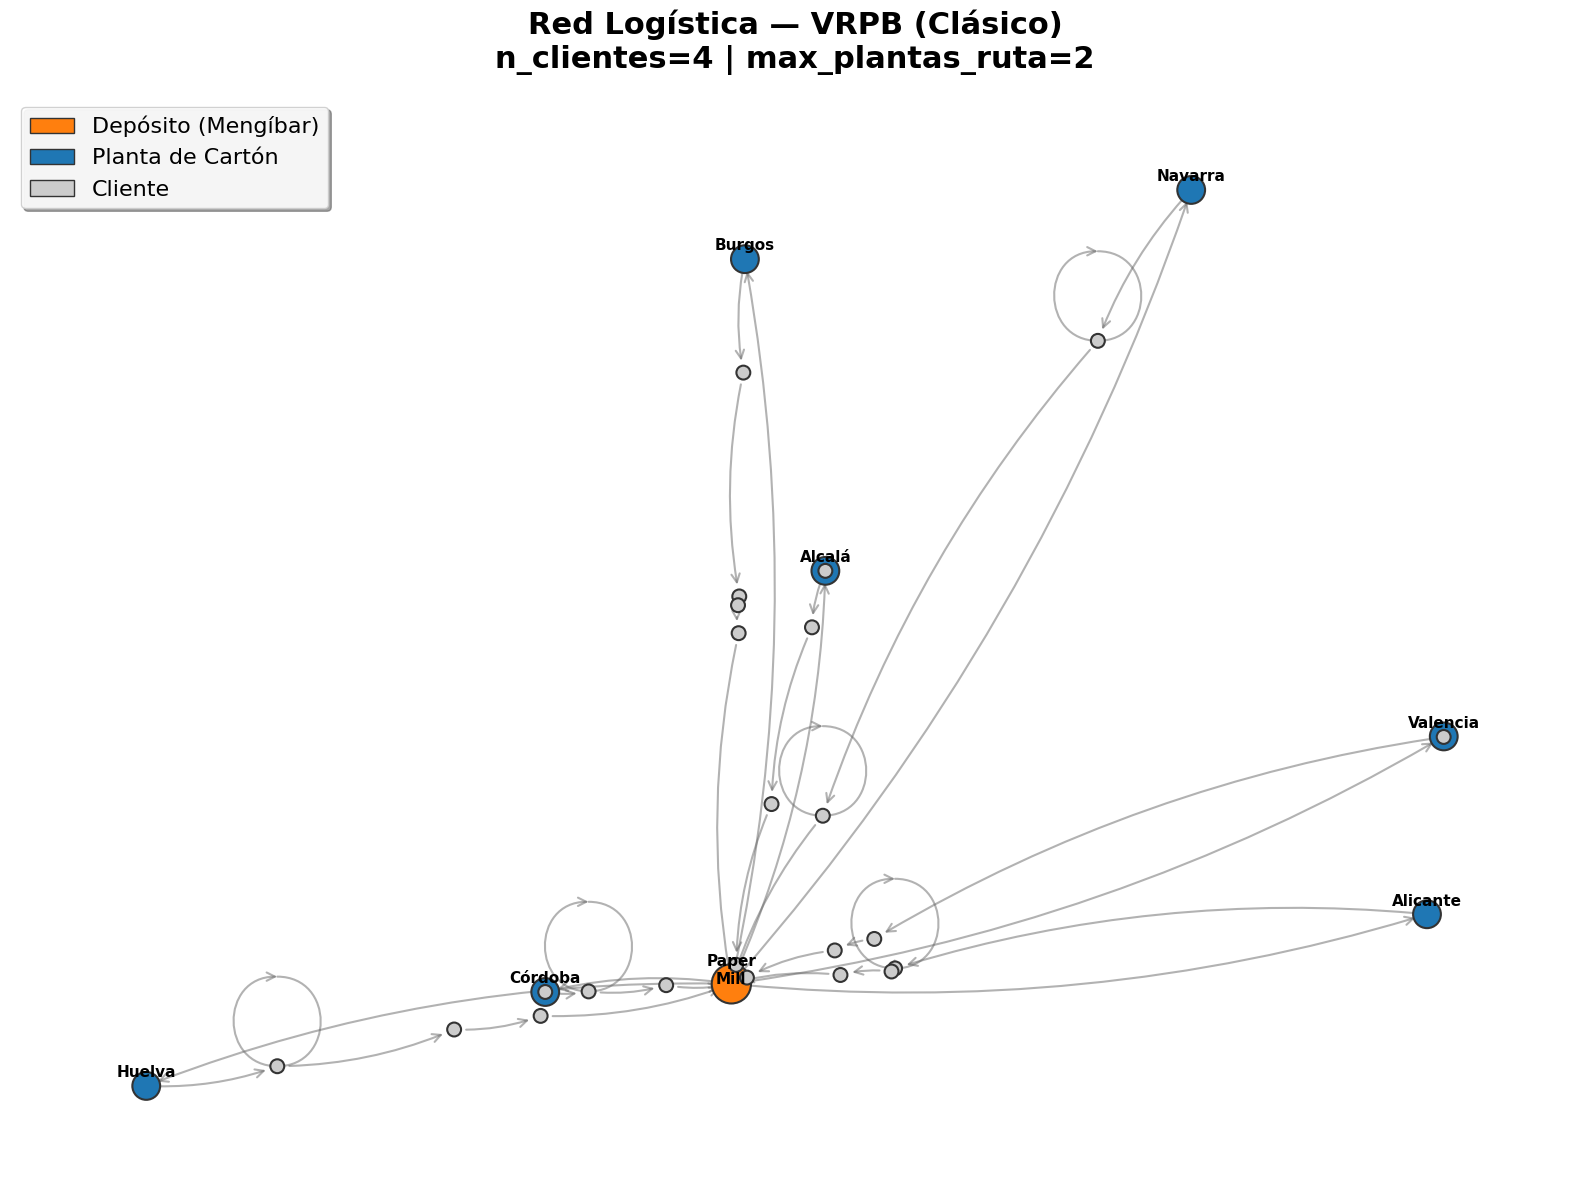

In [ ]:
if routes:
    G = nx.DiGraph()
    unique_nodes = {}
    
    for route in routes:
        for node in route:
            unique_nodes[node['id']] = node
            G.add_node(node['id'], name=node['name'], type=node['type'])
    
    for route in routes:
        for j in range(len(route) - 1):
            start, end = route[j], route[j+1]
            dist_km = solver.distance_matrix[start['matrix_idx']][end['matrix_idx']] / 1000
            G.add_edge(start['id'], end['id'], weight=round(dist_km, 1))
    
    print(f"Grafo: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")

if routes:
    node_colors = []
    node_sizes = []
    labels = {}
    
    for node_id in G.nodes():
        n_data = unique_nodes[node_id]
        
        # Ocultar los nombres de los clientes, mantener Depósito y Plantas
        if n_data['type'] == 'customer':
            labels[node_id] = ''
        else:
            words = n_data['name'].replace('Smurfit Westrock ', '').split()
            short_name = '\n'.join(words[:2]) if len(words) > 1 else words[0] if words else ''
            labels[node_id] = short_name
        
        # Tamaños de nodos más pequeños
        if n_data['type'] == 'depot':
            node_colors.append('#ff7f0e'); node_sizes.append(800)
        elif n_data['type'] == 'carton_plant':
            node_colors.append('#1f77b4'); node_sizes.append(400)
        else:
            node_colors.append('#cccccc'); node_sizes.append(100)
    
    fig, ax = plt.subplots(1, 1, figsize=(16, 12), facecolor='white')
    
    # 1. Posiciones base de los nodos
    pos = {n: (unique_nodes[n]['lng'], unique_nodes[n]['lat']) for n in G.nodes()}
    
    # 2. Desplazamiento en el eje 'y' (hacia arriba) para que las etiquetas no tapen los círculos
    # (El valor 0.05 depende de tu latitud geográfica, puedes aumentarlo a 0.1 o más si los puntos están muy cerca)
    label_pos = {n: (pos[n][0], pos[n][1] + 0.08) for n in pos}
    
    # Dibujar las lineas con curvas, PERO SIN dibujar 'edge_labels' de los km
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.5, width=1.5, edge_color='#666666',
        arrows=True, arrowsize=15, arrowstyle='->', connectionstyle='arc3,rad=0.1')
    
    # Hemos eliminado la sección 'nx.draw_networkx_edge_labels'
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
        edgecolors='#333333', linewidths=1.5, alpha=1.0)
        
    # Dibujar las etiquetas usando la nueva posición 'label_pos' (arriba del nodo)
    nx.draw_networkx_labels(G, label_pos, ax=ax, labels=labels, font_size=11,
        font_family='sans-serif', font_weight='bold', font_color='black')
    
    legend_handles = [
        mpatches.Patch(facecolor='#ff7f0e', edgecolor='#333', label='Depósito (Mengíbar)'),
        mpatches.Patch(facecolor='#1f77b4', edgecolor='#333', label='Planta de Cartón'),
        mpatches.Patch(facecolor='#cccccc', edgecolor='#333', label='Cliente'),
    ]
    
    ax.legend(handles=legend_handles, loc='upper left', fontsize=16,
              framealpha=0.9, fancybox=True, shadow=True)
    
    mode_str = 'MC-VRPB (Multi-Planta)' if VARIAS_PLANTAS else 'VRPB (Clásico)'
    ax.set_title(f'Red Logística — {mode_str}\nn_clientes={N_CLIENTES} | max_plantas_ruta={MAX_PLANTAS_RUTA}',
                fontsize=22, fontweight='bold', pad=20)
    
    # Mantener bordes o caja visible
    ax.axis('off')
    plt.tight_layout()
    
    graph_img_path = RESULTS_DIR / 'Logistics_Graph_NetworkX.png'
    fig.savefig(graph_img_path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f' Grafo guardado en: {graph_img_path}')
    plt.show()


---
## 6. 📈 Conclusiones y KPIs

In [30]:
if routes:
    mode_label = 'MC-VRPB (Multi-Planta)' if VARIAS_PLANTAS else 'VRPB (Clásico)'
    
    print('╔' + '═' * 58 + '╗')
    print('║' + f'  📊 KPIs — {mode_label}'.center(58) + '║')
    print('╠' + '═' * 58 + '╣')
    print(f'║  🚛 Rutas generadas:         {len(routes):>3}' + ' ' * 22 + '║')
    print(f'║  📍 Nodos optimizados:       {len(solver.nodes):>3}' + ' ' * 22 + '║')
    print(f'║  🏭 Plantas de cartón:       {sum(1 for n in solver.nodes if n["type"]=="carton_plant"):>3}' + ' ' * 22 + '║')
    print(f'║  🏪 Clientes atendidos:      {sum(1 for n in solver.nodes if n["type"]=="customer"):>3}' + ' ' * 22 + '║')
    print(f'║  🏁 Kilómetros totales:   {total_km:>8.2f} km' + ' ' * 14 + '║')
    print(f'║  📡 Fuente de distancias:    {"GPS Real" if solver.is_real_road else "Haversine":>12}' + ' ' * 12 + '║')
    print('╠' + '─' * 58 + '╣')
    print('║' + '  Parámetros:'.ljust(58) + '║')
    print(f'║    n_clientes={N_CLIENTES}  varias_plantas={VARIAS_PLANTAS}  max_plantas={MAX_PLANTAS_RUTA}'.ljust(59) + '║')
    print('╠' + '─' * 58 + '╣')
    print('║' + '  Detalle por ruta:'.ljust(58) + '║')
    print('╠' + '─' * 58 + '╣')
    
    for r in results_table:
        plants_short = ' + '.join(p.replace('Smurfit Westrock ', '') for p in r['plants'])
        multi = '🔄' if r['num_plants'] > 1 else '  '
        line = f"  R{r['route_id']}: {plants_short:<25} {r['num_customers']}c {r['distance_km']:>7.1f}km {multi}"
        print(f'║{line:<58}║')
    
    print('╚' + '═' * 58 + '╝')
    
    total_cust = sum(r['num_customers'] for r in results_table)
    if total_cust > 0:
        print(f'\n⚡ Eficiencia: {total_km / total_cust:.1f} km/cliente')
    print(f'📁 Archivos: {RESULTS_DIR}')

╔══════════════════════════════════════════════════════════╗
║                  📊 KPIs — VRPB (Clásico)                 ║
╠══════════════════════════════════════════════════════════╣
║  🚛 Rutas generadas:           7                      ║
║  📍 Nodos optimizados:        36                      ║
║  🏭 Plantas de cartón:         7                      ║
║  🏪 Clientes atendidos:       28                      ║
║  🏁 Kilómetros totales:    4569.66 km              ║
║  📡 Fuente de distancias:       Haversine            ║
╠──────────────────────────────────────────────────────────╣
║  Parámetros:                                             ║
║    n_clientes=4  varias_plantas=False  max_plantas=2     ║
╠──────────────────────────────────────────────────────────╣
║  Detalle por ruta:                                       ║
╠──────────────────────────────────────────────────────────╣
║  R1: Córdoba                   4c   153.6km              ║
║  R2: Huelva                    4c   502.1km       